# Improved Synthetic Data Generator (v2)

This notebook generates improved training data with:
- **6 intents** (order_status, payment_info, product_price, product_stock, product_description, out_of_scope)
- **Dynamic product fetching** from Bagisto database
- **More aggressive noise** (typos, abbreviations, slang)
- **Better coverage** of edge cases

In [1]:
# Cell 1: Imports and Setup
import os
import sys
import random
import json
import pandas as pd
import numpy as np
from pathlib import Path
from typing import List, Dict, Optional
import mysql.connector
from mysql.connector import Error

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

# Project paths
PROJECT_ROOT = Path(os.getcwd()).parent
DATA_DIR = PROJECT_ROOT / "data" / "synthetic"
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")

Project root: /Users/firas/Developer/skripsi-balor
Data directory: /Users/firas/Developer/skripsi-balor/data/synthetic


In [2]:
# Cell 2: Database Configuration
# Update these values to match your Bagisto database

DB_CONFIG = {
    'host': 'localhost',
    'user': 'root',
    'password': '',
    'database': 'bagisto_db',
    'port': 3306
}

print("Database configuration:")
print(f"  Host: {DB_CONFIG['host']}")
print(f"  Database: {DB_CONFIG['database']}")
print(f"  Port: {DB_CONFIG['port']}")

Database configuration:
  Host: localhost
  Database: bagisto_db
  Port: 3306


In [9]:
# Cell 3: Dynamic Product Fetching from Bagisto

def fetch_products_from_bagisto(db_config: dict) -> List[str]:
    """
    Dynamically fetch product names from Bagisto database.
    This ensures training data always reflects current inventory.
    
    Returns:
        List of product names and keywords for synthetic data
    """
    products = []
    
    try:
        print("Connecting to Bagisto database...")
        conn = mysql.connector.connect(**db_config)
        cursor = conn.cursor(dictionary=True)
        
        # Fetch all active product names
        query = """
            SELECT DISTINCT
                pf.name,
                pf.short_description,
                pf.sku
            FROM product_flat pf
            WHERE pf.status = 1
              AND pf.visible_individually = 1
              AND pf.name IS NOT NULL
        """
        
        cursor.execute(query)
        results = cursor.fetchall()
        
        print(f"Found {len(results)} products in database")
        
        for row in results:
            name = row['name']
            products.append(name)
            
            # Also add individual words from product name as keywords
            # e.g., "Arctic Cozy Knit Beanie" -> ["arctic", "cozy", "knit", "beanie"]
            words = name.lower().split()
            for word in words:
                # Filter out common stopwords and short words
                if len(word) > 3 and word not in ['with', 'from', 'this', 'that', 'your']:
                    if word not in products:
                        products.append(word)
            
            # Add keywords from description
            desc = row.get('short_description', '') or ''
            desc_words = desc.lower().split()[:10]  # First 10 words
            for word in desc_words:
                if len(word) > 4 and word.isalpha() and word not in products:
                    products.append(word)
        
        cursor.close()
        conn.close()
        
        print(f"Extracted {len(products)} product keywords")
        
    except Error as e:
        print(f"Database connection error: {e}")
        print("Using fallback generic product terms...")
        # Fallback to generic Indonesian product terms
        products = [
            "produk", "barang", "item",
            "topi", "baju", "celana", "sepatu", "tas",
            "aksesoris", "pakaian", "fashion",
            "jacket", "jaket", "kaos", "kemeja",
            "sarung tangan", "syal", "scarf", "beanie"
        ]
    
    return list(set(products))  # Remove duplicates

# Fetch products from database
PRODUCTS = fetch_products_from_bagisto(DB_CONFIG)
print(f"\nLoaded {len(PRODUCTS)} product keywords")
print(f"Sample products: {PRODUCTS[:10]}")

Connecting to Bagisto database...
Found 22 products in database
Extracted 94 product keywords

Loaded 93 product keywords
Sample products: ['sentuh', 'unmatched', 'winter', 'wool', 'jacket-blue-yellow-m', "OmniHeat Men's Solid Hooded Puffer Jacket", 'stylish', 'Jaket Puffer Pria OmniHeat Solid Bertudung-Biru-Hijau-M', 'omniheat', 'bliss']


In [10]:
# Cell 4: Define Entity Lists

# Order IDs - various formats
ORDER_IDS = [
    "12345", "67890", "1", "99", "123", "456", "789",
    "#12345", "#1", "#99",
    "ORD-001", "ORD001", "ORD123",
    "nomor 555", "nomor 123",
    "id 7788", "order-123", "pesanan 999"
]

# Payment methods - Indonesian e-wallets and banks
PAYMENT_METHODS = [
    # E-wallets
    "gopay", "ovo", "dana", "shopeepay", "linkaja", "jenius",
    # Banks
    "transfer bank", "bca", "mandiri", "bni", "bri", "cimb", "permata",
    # Others
    "cod", "cash", "cash on delivery", "bayar di tempat",
    "credit card", "kartu kredit", "debit", "kartu debit",
    "qris", "virtual account", "va",
    "cicilan", "kredivo", "akulaku"
]

print(f"Order ID formats: {len(ORDER_IDS)}")
print(f"Payment methods: {len(PAYMENT_METHODS)}")
print(f"Products: {len(PRODUCTS)}")

Order ID formats: 18
Payment methods: 27
Products: 93


In [11]:
# Cell 5: Intent Patterns - 6 Intents

# ============================================================
# 1. ORDER STATUS PATTERNS
# ============================================================
ORDER_STATUS_PATTERNS = [
    # Base patterns
    "cek pesanan {order_id}",
    "status order {order_id}",
    "pesanan {order_id} udah sampai mana",
    "tracking pesanan {order_id}",
    "orderan saya gimana",
    "mau cek status pesanan",
    "barang saya udah dikirim belum",
    "order {order_id} udah diproses belum",
    "kapan pesanan {order_id} sampai",
    "estimasi pengiriman order {order_id}",
    "lacak pesanan {order_id}",
    "dimana pesanan saya",
    "paket saya sudah sampai mana",
    "cek resi {order_id}",
    "status pengiriman {order_id}",
    
    # Casual/slang
    "order gue {order_id} mana",
    "pesanan gw {order_id} kemana",
    "brg {order_id} dmn",
    "udah dikirim blm {order_id}",
    "kok lama bgt order {order_id}",
    "mana nih orderan gw",
    "orderan gw kok ga nyampe",
    
    # Verbose
    "halo min mau tanya dong pesanan saya nomor {order_id} itu udah sampai mana ya",
    "permisi kak orderan saya yang {order_id} kok belum dateng",
    "maaf ganggu mau cek status order {order_id} dong",
    "kak mau tanya pesanan saya dengan nomor {order_id} sudah diproses belum ya",
    "selamat siang admin saya mau cek status pesanan nomor {order_id}",
]

# ============================================================
# 2. PAYMENT INFO PATTERNS
# ============================================================
PAYMENT_INFO_PATTERNS = [
    # Base patterns
    "metode pembayaran apa aja",
    "bisa bayar pakai {payment_method}",
    "cara bayar gimana",
    "accept {payment_method} ga",
    "pembayaran via apa",
    "terima {payment_method} tidak",
    "ada cicilan ga",
    "bisa transfer bank",
    "support ewallet ga",
    "bayar pake apa",
    "metode payment",
    "opsi pembayaran",
    "cara bayar orderan",
    
    # Casual/slang
    "bayar pake apa sih",
    "bs {payment_method} g",
    "pake {payment_method} bs?",
    "metode byr apa",
    "byr dmn",
    "terima {payment_method} gak",
    
    # Verbose
    "mau tanya untuk pembayarannya bisa pakai metode apa aja ya",
    "kalo mau bayar pake {payment_method} bisa ga min",
    "halo admin mau nanya pembayaran bisa pakai apa saja ya",
    "permisi kak untuk pembayaran tersedia metode apa saja",
]

# ============================================================
# 3. PRODUCT PRICE PATTERNS
# ============================================================
PRODUCT_PRICE_PATTERNS = [
    # Base patterns
    "harga {product} berapa",
    "berapa harga {product}",
    "{product} harganya berapa",
    "price {product}",
    "{product} berapa duit",
    "kisaran harga {product}",
    "range harga {product}",
    "biaya {product}",
    "{product} mahal ga",
    "{product} murah ga",
    "harga {product} sekarang",
    
    # Casual/slang
    "hrg {product} brp",
    "{product} brp duit",
    "brp {product}",
    "duit {product}",
    "{product} brp sih",
    
    # Verbose
    "mau tanya dong harga {product} yang ada di toko berapa ya",
    "kira kira {product} itu harganya berapa ya kak",
    "permisi mau nanya harga untuk {product} berapa ya",
    "boleh tau harga {product} tidak",
]

# ============================================================
# 4. PRODUCT STOCK PATTERNS
# ============================================================
PRODUCT_STOCK_PATTERNS = [
    # Base patterns
    "stok {product} ada",
    "{product} ready stock",
    "{product} masih ada",
    "tersedia {product} ga",
    "available {product}",
    "{product} kosong ga",
    "sisa stok {product}",
    "stock {product} berapa",
    "{product} ready ga",
    "ketersediaan {product}",
    "{product} habis belum",
    
    # Casual/slang
    "ad stok {product} g",
    "{product} ready?",
    "{product} msh ad?",
    "stok {product} abis blm",
    "{product} sold out?",
    
    # Verbose
    "mau tanya apakah {product} masih tersedia stoknya",
    "kak {product} masih ada ga stoknya",
    "halo min mau nanya {product} masih ready stock tidak ya",
    "permisi apakah stok {product} masih tersedia",
]

# ============================================================
# 5. PRODUCT DESCRIPTION PATTERNS
# ============================================================
PRODUCT_DESCRIPTION_PATTERNS = [
    # Base patterns
    "info produk {product}",
    "detail {product}",
    "spesifikasi {product}",
    "deskripsi {product}",
    "{product} terbuat dari apa",
    "bahan {product} apa",
    "fitur {product}",
    "kelebihan {product}",
    "{product} ukurannya apa aja",
    "warna {product} ada apa aja",
    "spec {product}",
    "{product} bagus ga",
    "review {product}",
    
    # Casual/slang
    "{product} gmn sih",
    "spec {product}",
    "{product} kyk gmn",
    "dtl {product}",
    
    # Verbose
    "bisa dijelasin tentang produk {product} dong",
    "mau tau lebih detail tentang {product}",
    "kak boleh tau spesifikasi {product} tidak",
    "tolong jelasin tentang {product} dong",
]

# ============================================================
# 6. OUT OF SCOPE PATTERNS
# ============================================================
OUT_OF_SCOPE_PATTERNS = [
    # Refund/return
    "mau refund",
    "cara refund gimana",
    "bisa return barang ga",
    "mau kembalikan barang",
    "uang saya kapan dikembalikan",
    "proses refund berapa lama",
    "tukar barang",
    "barang tidak sesuai mau tukar",
    
    # Complaints
    "barang rusak",
    "mau komplain",
    "produk tidak sesuai",
    "kecewa sama pelayanan",
    "barang cacat",
    "produk beda sama gambar",
    "kualitas jelek",
    
    # Store info
    "jam buka toko",
    "alamat toko dimana",
    "lokasi warehouse",
    "bisa ambil langsung ga",
    "ada toko offline",
    "alamat kantor",
    "nomor telepon toko",
    
    # Order modification
    "cancel pesanan",
    "batalkan order",
    "ubah alamat pengiriman",
    "ganti ukuran",
    "tambah item ke pesanan",
    "edit pesanan",
    
    # Other
    "mau kerja disini",
    "lowongan kerja ada ga",
    "jadi reseller gimana",
    "program affiliate",
    "kerjasama bisnis",
    
    # Greetings/random
    "halo",
    "hai",
    "test",
    "siapa kamu",
    "kamu bot ya",
    "cuaca hari ini gimana",
    "apa kabar",
]

print(f"\nPattern counts:")
print(f"  order_status: {len(ORDER_STATUS_PATTERNS)}")
print(f"  payment_info: {len(PAYMENT_INFO_PATTERNS)}")
print(f"  product_price: {len(PRODUCT_PRICE_PATTERNS)}")
print(f"  product_stock: {len(PRODUCT_STOCK_PATTERNS)}")
print(f"  product_description: {len(PRODUCT_DESCRIPTION_PATTERNS)}")
print(f"  out_of_scope: {len(OUT_OF_SCOPE_PATTERNS)}")


Pattern counts:
  order_status: 27
  payment_info: 23
  product_price: 20
  product_stock: 20
  product_description: 21
  out_of_scope: 40


In [12]:
# Cell 6: Noise Functions (More Aggressive)

# Indonesian typo mappings
INDONESIAN_TYPO_MAP = {
    'a': ['4', '@', ''],
    'e': ['3', ''],
    'i': ['1', '!', ''],
    'o': ['0', ''],
    's': ['$', '5'],
    'g': ['6', '9'],
}

# Common Indonesian abbreviations
ABBREVIATIONS = {
    'yang': 'yg',
    'dengan': 'dgn',
    'sudah': 'udh',
    'belum': 'blm',
    'tidak': 'ga',
    'bisa': 'bs',
    'bagaimana': 'gmn',
    'gimana': 'gmn',
    'dimana': 'dmn',
    'kemana': 'kmn',
    'kapan': 'kpn',
    'kenapa': 'knp',
    'berapa': 'brp',
    'harga': 'hrg',
    'barang': 'brg',
    'pesanan': 'psnan',
    'tolong': 'tlg',
    'terima kasih': 'makasih',
    'makasih': 'thx',
    'saya': 'sy',
    'aku': 'ak',
    'kamu': 'km',
    'ada': 'ad',
    'atau': 'ato',
    'untuk': 'utk',
    'sudah': 'sdh',
    'sampai': 'smp',
}

# Casual prefixes and suffixes
PREFIXES = ["", "halo", "hi", "hai", "permisi", "min", "kak", "gan", "misi", "bang", "sis", "admin", "bos", "mas", "mba"]
SUFFIXES = ["", "dong", "ya", "pls", "please", "tolong", "thanks", "thx", "makasih", "?", "??", "ya kak", "min"]

def introduce_typo(text: str, prob: float = 0.3) -> str:
    """Add typos with given probability"""
    if random.random() > prob or len(text) < 5:
        return text
    
    words = text.split()
    if not words:
        return text
    
    # Apply typo to 1-2 words
    num_typos = random.randint(1, min(2, len(words)))
    
    for _ in range(num_typos):
        word_idx = random.randint(0, len(words) - 1)
        word = words[word_idx]
        
        if len(word) > 3:
            typo_type = random.choice(['remove', 'swap', 'replace', 'double'])
            
            if typo_type == 'remove':
                # Remove random character
                char_idx = random.randint(1, len(word) - 2)
                word = word[:char_idx] + word[char_idx+1:]
            
            elif typo_type == 'swap':
                # Swap adjacent characters
                if len(word) > 2:
                    char_idx = random.randint(0, len(word) - 2)
                    word = word[:char_idx] + word[char_idx+1] + word[char_idx] + word[char_idx+2:]
            
            elif typo_type == 'replace':
                # Replace with similar character
                char_idx = random.randint(0, len(word) - 1)
                char = word[char_idx].lower()
                if char in INDONESIAN_TYPO_MAP:
                    replacement = random.choice(INDONESIAN_TYPO_MAP[char])
                    word = word[:char_idx] + replacement + word[char_idx+1:]
            
            elif typo_type == 'double':
                # Double a character
                char_idx = random.randint(0, len(word) - 1)
                word = word[:char_idx] + word[char_idx] + word[char_idx:]
        
        words[word_idx] = word
    
    return " ".join(words)

def apply_abbreviation(text: str, prob: float = 0.25) -> str:
    """Apply common Indonesian abbreviations"""
    if random.random() > prob:
        return text
    
    text_lower = text.lower()
    for full, abbrev in ABBREVIATIONS.items():
        if full in text_lower and random.random() < 0.5:
            text = text.replace(full, abbrev)
            text = text.replace(full.capitalize(), abbrev)
    
    return text

def wrap_casual(text: str, prob: float = 0.4) -> str:
    """Add casual prefix/suffix"""
    if random.random() > prob:
        return text
    
    prefix = random.choice(PREFIXES)
    suffix = random.choice(SUFFIXES)
    
    if prefix:
        text = f"{prefix} {text}"
    if suffix and not text.endswith('?'):
        text = f"{text} {suffix}"
    
    return text.strip()

def add_noise(text: str, noise_level: str = "medium") -> str:
    """Apply noise based on level"""
    
    # Noise probabilities by level
    noise_config = {
        "low": {"typo": 0.1, "abbrev": 0.1, "casual": 0.2},
        "medium": {"typo": 0.25, "abbrev": 0.25, "casual": 0.35},
        "high": {"typo": 0.4, "abbrev": 0.4, "casual": 0.5},
        "extreme": {"typo": 0.6, "abbrev": 0.6, "casual": 0.7},
    }
    
    config = noise_config.get(noise_level, noise_config["medium"])
    
    # Apply transformations
    text = apply_abbreviation(text, config["abbrev"])
    text = introduce_typo(text, config["typo"])
    text = wrap_casual(text, config["casual"])
    
    # Random case variation
    case_choice = random.choice(["lower", "original", "capitalize"])
    if case_choice == "lower":
        text = text.lower()
    elif case_choice == "capitalize":
        text = text.capitalize()
    
    return text

# Test noise functions
print("Testing noise functions:")
test_text = "harga produk berapa"
for level in ["low", "medium", "high", "extreme"]:
    noisy = add_noise(test_text, level)
    print(f"  {level}: {noisy}")

Testing noise functions:
  low: hraga produk brapa
  medium: Harga produk brp
  high: mas harga produk berapa
  extreme: halo harga produk berapa tolong


In [13]:
# Cell 7: Data Generation Function

def generate_intent_data(
    patterns: List[str],
    intent_label: str,
    num_samples: int = 500,
    products: List[str] = None,
    order_ids: List[str] = None,
    payment_methods: List[str] = None
) -> List[Dict]:
    """
    Generate samples for a single intent
    
    Args:
        patterns: List of pattern templates
        intent_label: Intent label for these samples
        num_samples: Number of samples to generate
        products: List of product names (for product-related intents)
        order_ids: List of order ID formats
        payment_methods: List of payment method names
    
    Returns:
        List of sample dictionaries
    """
    data = []
    noise_levels = ["low", "medium", "high", "extreme"]
    noise_weights = [0.3, 0.4, 0.2, 0.1]  # Most samples are medium noise
    
    # Default entity lists
    products = products or PRODUCTS
    order_ids = order_ids or ORDER_IDS
    payment_methods = payment_methods or PAYMENT_METHODS
    
    for _ in range(num_samples):
        pattern = random.choice(patterns)
        
        # Replace placeholders
        if "{order_id}" in pattern:
            pattern = pattern.replace("{order_id}", random.choice(order_ids))
        if "{payment_method}" in pattern:
            pattern = pattern.replace("{payment_method}", random.choice(payment_methods))
        if "{product}" in pattern:
            pattern = pattern.replace("{product}", random.choice(products))
        
        # Apply noise
        noise_level = random.choices(noise_levels, weights=noise_weights)[0]
        text = add_noise(pattern, noise_level)
        
        data.append({
            "text": text,
            "intent": intent_label,
            "noise_level": noise_level
        })
    
    return data

print("Data generation function ready!")

Data generation function ready!


In [14]:
# Cell 8: Generate Full Dataset

SAMPLES_PER_INTENT = 500

print(f"Generating {SAMPLES_PER_INTENT} samples per intent...")
print("=" * 60)

dataset = []

# Generate samples for each intent
intents_config = [
    (ORDER_STATUS_PATTERNS, "order_status"),
    (PAYMENT_INFO_PATTERNS, "payment_info"),
    (PRODUCT_PRICE_PATTERNS, "product_price"),
    (PRODUCT_STOCK_PATTERNS, "product_stock"),
    (PRODUCT_DESCRIPTION_PATTERNS, "product_description"),
    (OUT_OF_SCOPE_PATTERNS, "out_of_scope"),
]

for patterns, intent_label in intents_config:
    samples = generate_intent_data(
        patterns=patterns,
        intent_label=intent_label,
        num_samples=SAMPLES_PER_INTENT,
        products=PRODUCTS,
        order_ids=ORDER_IDS,
        payment_methods=PAYMENT_METHODS
    )
    dataset.extend(samples)
    print(f"  Generated {len(samples)} samples for '{intent_label}'")

# Shuffle dataset
random.shuffle(dataset)

print(f"\nTotal samples: {len(dataset)}")

Generating 500 samples per intent...
  Generated 500 samples for 'order_status'
  Generated 500 samples for 'payment_info'
  Generated 500 samples for 'product_price'
  Generated 500 samples for 'product_stock'
  Generated 500 samples for 'product_description'
  Generated 500 samples for 'out_of_scope'

Total samples: 3000


In [15]:
# Cell 9: Create DataFrame and Analyze

df = pd.DataFrame(dataset)

print("Dataset Statistics:")
print("=" * 60)

print(f"\nIntent distribution:")
print(df['intent'].value_counts())

print(f"\nNoise level distribution:")
print(df['noise_level'].value_counts())

print(f"\nText length statistics:")
df['text_length'] = df['text'].str.len()
print(df['text_length'].describe())

Dataset Statistics:

Intent distribution:
intent
product_description    500
payment_info           500
out_of_scope           500
product_price          500
product_stock          500
order_status           500
Name: count, dtype: int64

Noise level distribution:
noise_level
medium     1193
low         921
high        588
extreme     298
Name: count, dtype: int64

Text length statistics:
count    3000.000000
mean       29.795333
std        18.007467
min         3.000000
25%        17.000000
50%        24.000000
75%        37.000000
max       107.000000
Name: text_length, dtype: float64


In [16]:
# Cell 10: Show Sample Data for Each Intent

print("\nSample data for each intent:")
print("=" * 60)

for intent in df['intent'].unique():
    print(f"\n{'='*20} {intent.upper()} {'='*20}")
    samples = df[df['intent'] == intent]['text'].head(8).tolist()
    for i, s in enumerate(samples, 1):
        print(f"  {i}. {s}")


Sample data for each intent:

==================== PRODUCT_DESCRIPTION ====================
  1. Spesifikai kupluk
  2. kak boleh tau spesifikasi arctic touchscreen winter gloves tidak
  3. Mau tau lebih detail tentang jacket
  4. Info produk bertudung-biru-hijau-m
  5. Kak boleh tau spesifikasi arctic bliss stylish winter scarf tidak ya
  6. misi deskrpsi penh tolong
  7. gan info produk gaya
  8. kak boleh tau spesifikasi arctic touchscreen winter gloves ga

==================== PAYMENT_INFO ====================
  1. Bos bayar ppake apa ??
  2. bayar pake apa sih
  3. kak permisi kak utk pembayaran tersedia metode apa saja min
  4. Bs cod g
  5. ada cicilan ga
  6. Admin metode pembayar@n apa aja tolong
  7. Admin opsi pembayaran thx
  8. Pembayaran via apa

==================== OUT_OF_SCOPE ====================
  1. N0mor telepon toko
  2. Kamu bot ya
  3. halo uang sy kapan dikembalikan pls
  4. mau kembalikan barang
  5. barang cacat
  6. Sis lowongan ekraj ada ga min
  7. proses

In [17]:
# Cell 11: Save Dataset

# Remove helper column before saving
df_to_save = df.drop(columns=['text_length'])

# Save as CSV
csv_path = DATA_DIR / "intent_dataset_v2.csv"
df_to_save.to_csv(csv_path, index=False)
print(f"Dataset saved to: {csv_path}")

# Also save as JSON for reference
json_path = DATA_DIR / "intent_dataset_v2.json"
df_to_save.to_json(json_path, orient='records', indent=2, force_ascii=False)
print(f"JSON backup saved to: {json_path}")

# Save metadata
metadata = {
    "version": "v2",
    "total_samples": len(df),
    "samples_per_intent": SAMPLES_PER_INTENT,
    "intents": list(df['intent'].unique()),
    "noise_levels": list(df['noise_level'].unique()),
    "products_count": len(PRODUCTS),
    "products_source": "Bagisto database (dynamic)",
}

metadata_path = DATA_DIR / "dataset_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata saved to: {metadata_path}")

Dataset saved to: /Users/firas/Developer/skripsi-balor/data/synthetic/intent_dataset_v2.csv
JSON backup saved to: /Users/firas/Developer/skripsi-balor/data/synthetic/intent_dataset_v2.json
Metadata saved to: /Users/firas/Developer/skripsi-balor/data/synthetic/dataset_metadata.json


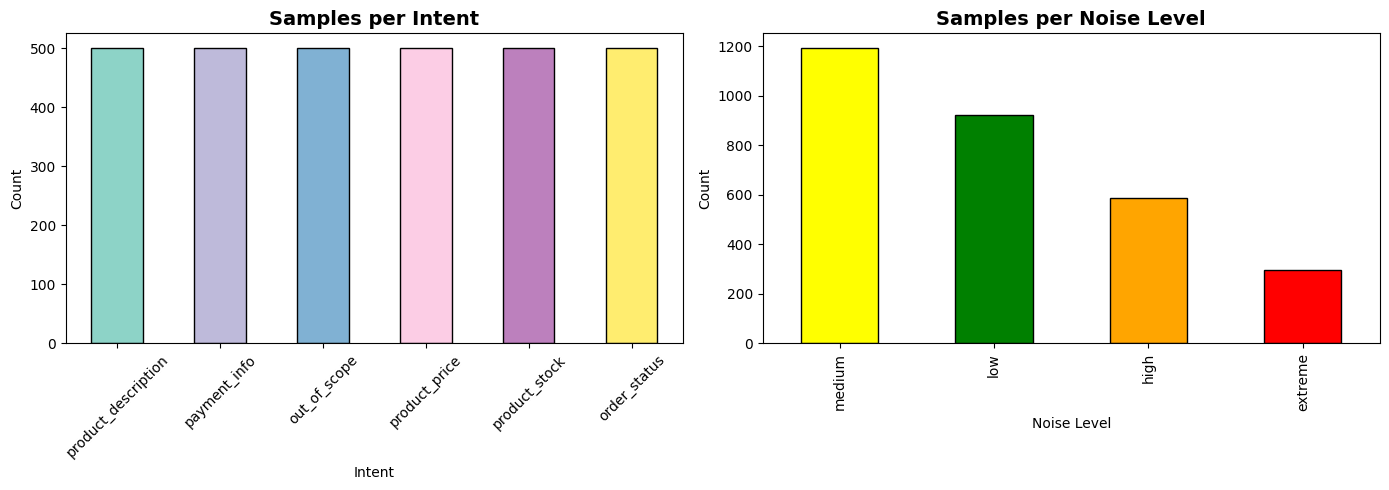


Figure saved to: /Users/firas/Developer/skripsi-balor/data/synthetic/dataset_distribution.png


In [18]:
# Cell 12: Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Intent distribution
ax1 = axes[0]
intent_counts = df['intent'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(intent_counts)))
intent_counts.plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('Samples per Intent', fontsize=14, fontweight='bold')
ax1.set_xlabel('Intent')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Noise level distribution
ax2 = axes[1]
noise_counts = df['noise_level'].value_counts()
noise_colors = {'low': 'green', 'medium': 'yellow', 'high': 'orange', 'extreme': 'red'}
noise_counts.plot(kind='bar', ax=ax2, color=[noise_colors.get(n, 'gray') for n in noise_counts.index], edgecolor='black')
ax2.set_title('Samples per Noise Level', fontsize=14, fontweight='bold')
ax2.set_xlabel('Noise Level')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.savefig(DATA_DIR / 'dataset_distribution.png', dpi=300)
plt.show()

print(f"\nFigure saved to: {DATA_DIR / 'dataset_distribution.png'}")

In [19]:
# Cell 13: Summary

print("\n" + "=" * 60)
print("DATA GENERATION COMPLETE!")
print("=" * 60)

print(f"""
Summary:
--------
- Total samples: {len(df)}
- Intents: 6 ({', '.join(df['intent'].unique())})
- Samples per intent: {SAMPLES_PER_INTENT}
- Products from database: {len(PRODUCTS)}

Files created:
--------------
1. {csv_path}
2. {json_path}
3. {metadata_path}
4. {DATA_DIR / 'dataset_distribution.png'}

Next steps:
-----------
1. Review sample data quality
2. Proceed to notebook 03 for model training
""")


DATA GENERATION COMPLETE!

Summary:
--------
- Total samples: 3000
- Intents: 6 (product_description, payment_info, out_of_scope, product_price, product_stock, order_status)
- Samples per intent: 500
- Products from database: 93

Files created:
--------------
1. /Users/firas/Developer/skripsi-balor/data/synthetic/intent_dataset_v2.csv
2. /Users/firas/Developer/skripsi-balor/data/synthetic/intent_dataset_v2.json
3. /Users/firas/Developer/skripsi-balor/data/synthetic/dataset_metadata.json
4. /Users/firas/Developer/skripsi-balor/data/synthetic/dataset_distribution.png

Next steps:
-----------
1. Review sample data quality
2. Proceed to notebook 03 for model training

